### 1. Introducción
El proceso de preprocesamiento se diseñará conforme a la metodología tradicional de construcción de scorecards de riesgo de crédito, ampliamente utilizada en banca para la estimación de la Probabilidad de Incumplimiento (PD) en modelos de Application Scoring.

A diferencia de los enfoques puramente basados en machine learning, el enfoque adoptado se basa en:

    - Discretización supervisada de variables,
    - Transformación mediante Weight of Evidence (WoE) para el conjunto train,

$$
    WoE_i = \ln \left( \frac{N_{Good,i} / N_{Good}}{N_{Bad,i} / N_{Bad}} \right)
$$

    - Evaluación de capacidad predictiva individual mediante Information Value (IV), el cual cuantifica la capacidad discriminante individual de cada variable, permitiendo clasificar su relevancia predictiva antes de la modelización multivariante.

$$
IV = \sum_{i} \left( \frac{N_{Good,i}}{N_{Good}} - \frac{N_{Bad,i}}{N_{Bad}} \right)
\cdot
\ln \left( \frac{N_{Good,i} / N_{Good}}{N_{Bad,i} / N_{Bad}} \right)
$$

    - Estimación de una regresión logística sobre variables transformadas.

Este enfoque garantiza:

    - Interpretabilidad económica,
    - Monotonicidad del riesgo,
    - Estabilidad paramétrica,
    - Coherencia con la práctica bancaria y los estándares regulatorios.

El preprocesamiento se realizará exclusivamente utilizando el conjunto de entrenamiento, evitando cualquier riesgo de data leakage y asegurando la validez fuera de muestra del modelo.

El objetivo del clásico scorecard es discretizar las variables para luego transformarlas a Weight Of Evidence. De esta manera conseguimos reducir el impacto de outliers, imponer monotonicidad y mejorar la interpretabilidad a traves de la explicación por tramos (bin).  
Al aplicar transformación mediante WoE, evitamos aplicar un pipeline de ML mas "genérico". En este caso, tenemos:  
    - Para categóricas transformamos cada categoría en un valor numérico continuo. Por lo tanto, las variables categóricas ya serán transformadas reflejando el riesgo entre default y no default. Concluyendo, no es necesario aplicar One One Enconding.   
    - Para numéricas no es necesario aplicar Standard Scaler ya que con WoE, las variables están en una escala comparable. Además, el propio WoE ya es  una transformación logarítmica basada en la razón de las probabilidades. De hecho, WoE está diseñada específicamente para encajar con la forma funcional de la regresión logística.  
    - Los valores faltantes se incorporarán como un bin específico dentro del proceso de discretización supervisada, permitiendo estimar su WoE de forma independiente y preservar la señal de riesgo asociada al patrón de ausencia de información.


In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
import numpy as np
import missingno as msno
#visualizacion
import matplotlib.pyplot as plt 
import seaborn as sns
# train y test
from sklearn.model_selection import train_test_split
#Librerias para binning (WoE)
import optbinning
from optbinning import OptimalBinning
import scorecardpy as sc
# modelos
import statsmodels.api as sm
import statsmodels.formula.api as smf
# métricas
from sklearn.metrics import roc_auc_score

(CVXPY) Apr 12 06:43:08 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.15.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Apr 12 06:43:08 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.15.0. Please open a feature request on cvxpy to enable support for this version.')


### 2. Carga y transformación de variables

In [3]:
# Cargar el dataset y hacer una copia
hmeq = pd.read_csv('data/hmeq.csv')
hmeq_prep = hmeq.copy()

In [4]:
# Creación de variable financiera LTV (Loan to Value)
# LTV = (LOAN + MORTDUE) / VALUE
# ratio entre el endeudamiento hipotecario total del cliente (deuda existente + nuevo préstamo solicitado) y el valor de tasación del inmueble.
# Justificación: Alta correlación (Spearman = 0.86) entre MORTDUE y VALUE.
# Objetivo: Evitar multicolinealidad
hmeq_prep["CLTV"] = np.where(
    (hmeq_prep["VALUE"].notna()) &
    (hmeq_prep["MORTDUE"].notna()) &
    (hmeq_prep["VALUE"] > 0),
    (hmeq_prep["LOAN"] + hmeq_prep["MORTDUE"]) / hmeq_prep["VALUE"],
    np.nan
)

In [5]:
hmeq_prep['CLTV'].describe().round(2)

count    5357.00
mean        0.91
std         0.44
min         0.09
25%         0.84
50%         0.90
75%         0.96
max         9.49
Name: CLTV, dtype: float64

In [6]:
# Información de MORTDUE y VALUE capturada con CLTV
# Elimnar columnas originales relacionadas 
hmeq_prep = hmeq_prep.drop(columns=["MORTDUE", "VALUE"])

In [7]:
hmeq_prep.head(10)

,BAD,LOAN,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC,CLTV
0,1,1100,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN,0.690839
1,1,1300,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN,1.043173
2,1,1500,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN,0.898204
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN,0.888393
5,1,1700,HomeImp,Other,9.0,0.0,0.0,101.466002,1.0,8.0,37.113614,0.799802
6,1,1800,HomeImp,Other,5.0,3.0,2.0,77.100000,1.0,17.0,NaN,0.884496
7,1,1800,HomeImp,Other,11.0,0.0,0.0,88.766030,0.0,8.0,36.884894,0.704141
8,1,2000,HomeImp,Other,3.0,0.0,2.0,216.933333,1.0,12.0,NaN,0.742405
9,1,2000,HomeImp,Sales,16.0,0.0,0.0,115.800000,0.0,13.0,NaN,NaN


### 3. Train y Test

In [8]:
# train y test split
train, test = train_test_split(hmeq_prep, test_size=0.3, random_state=123, stratify=hmeq_prep['BAD'])

In [9]:
# Número total de observaciones en train
n_train = len(train)
# Número de defaults (BAD = 1)
n_bad = train["BAD"].sum()
# Número de no-defaults (BAD = 0)
n_good = n_train - n_bad
# Tasa de default
default_rate = n_bad / n_train

print(f"Observaciones totales (train): {n_train}")
print(f"No defaults (Good): {n_good}")
print(f"Defaults (Bad): {n_bad}")
print(f"Tasa de default: {default_rate:.2%}")

Observaciones totales (train): 4172
No defaults (Good): 3340
Defaults (Bad): 832
Tasa de default: 19.94%


### 4. Information Value

In [ ]:
# Calcular el poder predictivo de las variables utilizando IV para el conjunto de entrenamiento
iv = sc.iv(train,  y="BAD")

# Reducir la precisión a 2 decimales y mostrar el resultado
pd.set_option("display.precision", 2)
print(iv)

   variable  info_value
6      LOAN        0.82
1    DELINQ        0.63
2     DEROG        0.41
7       YOJ        0.34
9      CLNO        0.24
5      NINQ        0.16
8       JOB        0.15
10    CLAGE        0.06
4   DEBTINC        0.04
3       LTV        0.04
0    REASON        0.01


Recordemos que IV es:

$$
IV = \sum_{i=1}^{n} (perct_{buenos,i} - perct_{malos,i}) \times WoE_i
$$

Mide como de bueno una variable separa las dos clases de la variable BAD. Nos da una señal de que variables son buenas predictoras cuando el valor es alto entre 0.3 y 0.5 mientras que una variable por debajo de 0.02 no aporta poder de predicción como es en nuestro caso la variable REASON. 

No obstante, la variable LOAN y DELINQ aportan demasiado IV y esto activa una alerta sospechosa de posible data leakage o una (muy) alta correlación con la variable target. 

La variable LOAN serán objeto de un mayor análisis cuando discreticemos las variables. 
En cambio, la variable DELINQ representa el número de veces que el cliente ha estado en mora en los últimos 12 meses. 
Un valor alto de DELINQ indica un historial crediticio problemático, lo que se asocia con un mayor riesgo de default. Es por ello,  que IV alto en continuo y binned es consistente con la naturaleza de la variable.


### 5. Discretización de variables con optimal binning

In [11]:
# Discretización supervisada  o agrupación de las variables (binning). Aplicaremos algoritmos de optimal binning y ajuste de modelo.
def variables_analysis(train, variable, direction):
    name = variable
    aux = train.loc[:, ["BAD", name]].copy() # En una copia, seleccionamos  vble objetivo y vble a analizar

    if aux[name].dtype == np.dtype("O"): # Si name es de tipo object
        aux[name] = aux[name].astype(str) # lo convertimos a string
        
    y = aux["BAD"] # Objetivo
    X = aux[name] # Explicativa

    dtype = "numerical" if np.issubdtype(train[variable].dtype, np.number) else "categorical"


# Crear el objeto OptimalBinning y ajustar el modelo
    optb = OptimalBinning(name=name,
                          monotonic_trend = direction, # puede ser "ascending" (BAD = 1 cuando variable "name" aumenta) o "descending" (BAD = 0 cuando variable "name" aumenta)
                          min_bin_size=0.05, max_n_bins=6,   # al menos 5% de datos en cada bin y máximo 6 bins
                          dtype=dtype) # Si la variable es numérica, numerical y si es categórica, categorical
    optb.fit(X, y) # Ajustar el modelo en train

    return(optb)

In [ ]:
# Importante entender:
# El parámetro monotonic_trend se refiere a la dirección del RIESGO respecto a la variable:
# "ascending"  → a mayor valor de la variable, mayor riesgo de default (ej: DELINQ, DEROG, NINQ)
# "descending" → a mayor valor de la variable, menor riesgo de default (ej: YOJ, CLNO, CLAGE)
# None         → sin restricción de monotonicidad (ej: LOAN, LTV — relación no lineal)
# Como el WoE es inversamente proporcional al riesgo, ascending produce WoE descendente y viceversa.
bin_LOAN   = variables_analysis(train, "LOAN", None) 
bin_DELINQ = variables_analysis(train, "DELINQ", "ascending")
bin_DEROG  = variables_analysis(train, "DEROG", "ascending")
bin_YOJ    = variables_analysis(train, "YOJ", "descending")
bin_CLNO   = variables_analysis(train, "CLNO", "descending")
bin_CLAGE   = variables_analysis(train, "CLAGE", "descending")
bin_NINQ   = variables_analysis(train, "NINQ", "ascending")
bin_LTV    = variables_analysis(train, "LTV", None)  # si tiene sentido
bin_DEBTINC = variables_analysis(train, "DEBTINC", "ascending")

### 6. Visualización de bin_variables

In [ ]:
# LOAN TABLE
bin_LOAN.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 6050.00)",230,0.06,119,111,0.48,-1.32,1.29e-01,1.51e-02
1,"[6050.00, 13950.00)",1410,0.34,1122,288,0.20,-0.03,3.07e-04,3.83e-05
2,"[13950.00, 15050.00)",229,0.05,160,69,0.30,-0.55,1.92e-02,2.37e-03
3,"[15050.00, 25050.00)",1488,0.36,1244,244,0.16,0.24,1.89e-02,2.36e-03
4,"[25050.00, 37950.00)",575,0.14,507,68,0.12,0.62,4.34e-02,5.34e-03
5,"[37950.00, inf)",240,0.06,188,52,0.22,-0.1,6.50e-04,8.13e-05
6,Special,0,0.00,0,0,0.00,0.0,0.00e+00,0.00e+00
7,Missing,0,0.00,0,0,0.00,0.0,0.00e+00,0.00e+00
Totals,,4172,1.00,3340,832,0.20,,2.12e-01,2.53e-02


'''Un matiz importante es el IV de LOAN. Mientras que en la variable continua IV era 0.82, ahora es 0.212. 
Esto se debe a que al discretizar la variable, se pierde parte de la información original.
Esto es positivo con los valores obtenidos ya que se reduce el ruido y evita sobreajuste mientras que el poder predictivo se mantiene.
Por lo tanto, El IV alto en continuo era ruido estadístico amplificado por la granularidad, no una señal de leakage '''


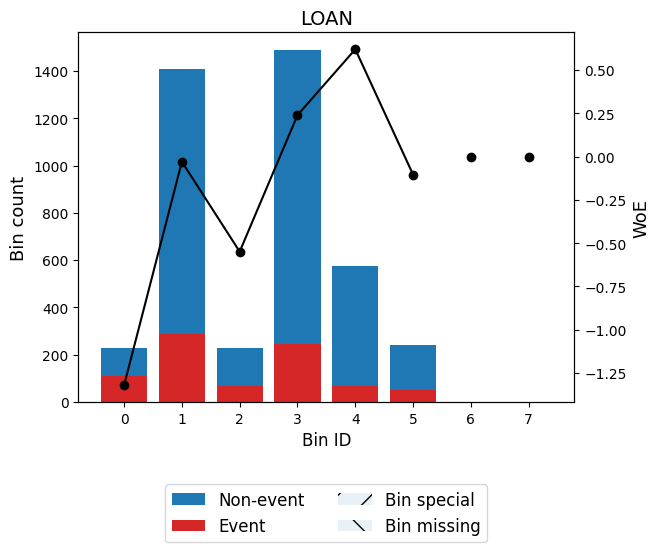

In [ ]:
# LOAN PLOT
bin_LOAN.binning_table.plot('woe')
# La relación no es monótona pero si es importante el alto nivel de default en el primer bin. Es decir, hay mayor riesgo en préstamos pequeños. 

In [ ]:
# DELINQ TABLE
bin_DELINQ.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.50)",2922,0.70,2515,407,0.14,0.43,0.11,1.41e-02
1,"[0.50, 2.50)",639,0.15,407,232,0.36,-0.83,0.13,1.58e-02
2,"[2.50, inf)",209,0.05,70,139,0.67,-2.08,0.30,3.23e-02
3,Special,0,0.00,0,0,0.00,0.0,0.00,0.00e+00
4,Missing,402,0.10,348,54,0.13,0.47,0.02,2.30e-03
Totals,,4172,1.00,3340,832,0.20,,0.57,6.45e-02


En este caso. El IV de DELINQ es alto tanto en continuo (0.63) como en binned (0.56). No obstante, comprender la variable es necesario. 
DELINQ representa el número de veces que el cliente ha estado en mora en los últimos 12 meses. 
Un valor alto de DELINQ indica un historial crediticio problemático, lo que se asocia con un mayor riesgo de default. Es por ello, 
que IV alto en continuo y binned es consistente con la naturaleza de la variable.

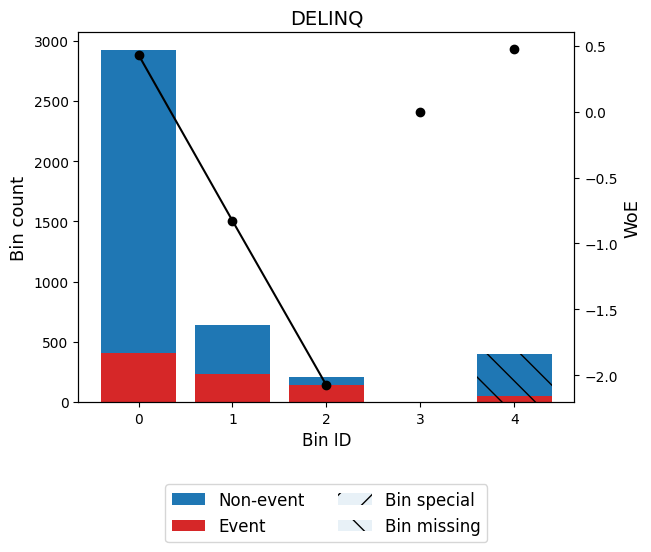

In [16]:
# DELINQ PLOT
bin_DELINQ.binning_table.plot("woe")

In [17]:
bin_DEROG.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.50)",3164,0.76,2641,523,0.17,0.23,0.04,4.64e-03
1,"[0.50, 1.50)",295,0.07,179,116,0.39,-0.96,0.08,9.88e-03
2,"[1.50, inf)",213,0.05,83,130,0.61,-1.84,0.24,2.66e-02
3,Special,0,0.00,0,0,0.00,0.0,0.00,0.00e+00
4,Missing,500,0.12,437,63,0.13,0.55,0.03,3.72e-03
Totals,,4172,1.00,3340,832,0.20,,0.39,4.48e-02


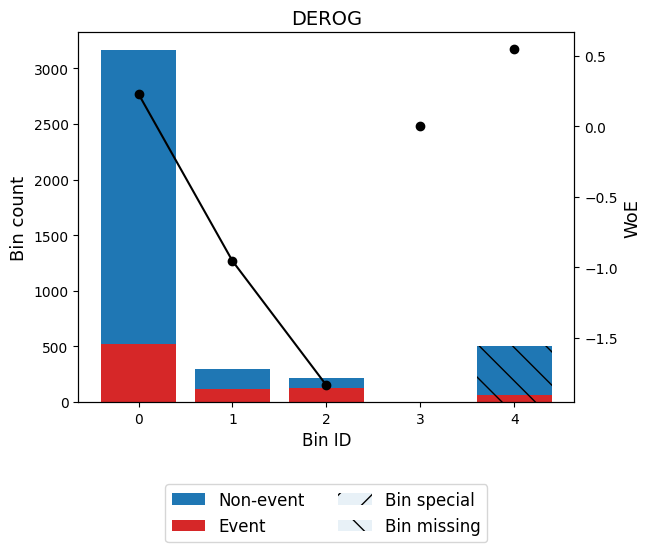

In [18]:
bin_DEROG.binning_table.plot("woe")

In [19]:
bin_YOJ.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 3.95)",1127,0.27,858,269,0.24,-0.23,1.53e-02,1.91e-03
1,"[3.95, 5.75)",472,0.11,363,109,0.23,-0.19,4.17e-03,5.21e-04
2,"[5.75, 20.50)",1827,0.44,1473,354,0.19,0.04,5.57e-04,6.97e-05
3,"[20.50, inf)",400,0.10,348,52,0.13,0.51,2.13e-02,2.63e-03
4,Special,0,0.00,0,0,0.00,0.0,0.00e+00,0.00e+00
5,Missing,346,0.08,298,48,0.14,0.44,1.37e-02,1.70e-03
Totals,,4172,1.00,3340,832,0.20,,5.51e-02,6.84e-03


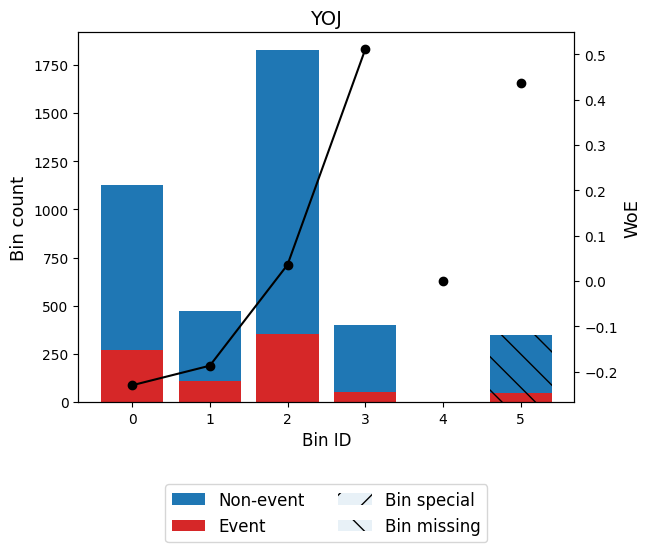

In [20]:
bin_YOJ.binning_table.plot("woe")

In [21]:
bin_CLNO.binning_table.build()


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 8.50)",304,0.07,199,105,0.35,-0.75,5.00e-02,6.11e-03
1,"[8.50, 14.50)",730,0.17,586,144,0.20,0.01,3.23e-05,4.04e-06
2,"[14.50, inf)",2983,0.72,2439,544,0.18,0.11,8.44e-03,1.05e-03
3,Special,0,0.00,0,0,0.00,0.0,0.00e+00,0.00e+00
4,Missing,155,0.04,116,39,0.25,-0.3,3.64e-03,4.54e-04
Totals,,4172,1.00,3340,832,0.20,,6.21e-02,7.62e-03


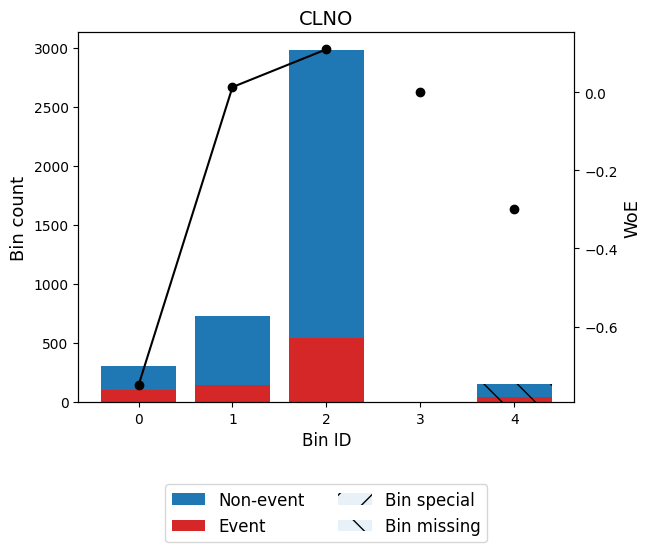

In [22]:
bin_CLNO.binning_table.plot("woe")


In [23]:
bin_CLAGE.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 73.20)",245,0.06,148,97,0.40,-0.97,6.99e-02,8.41e-03
1,"[73.20, 122.92)",954,0.23,698,256,0.27,-0.39,3.82e-02,4.74e-03
2,"[122.92, 172.50)",765,0.18,596,169,0.22,-0.13,3.20e-03,3.99e-04
3,"[172.50, 217.18)",841,0.20,712,129,0.15,0.32,1.85e-02,2.30e-03
4,"[217.18, 239.24)",274,0.07,240,34,0.12,0.56,1.75e-02,2.16e-03
5,"[239.24, inf)",871,0.21,784,87,0.10,0.81,1.05e-01,1.28e-02
6,Special,0,0.00,0,0,0.00,0.0,0.00e+00,0.00e+00
7,Missing,222,0.05,162,60,0.27,-0.4,9.37e-03,1.16e-03
Totals,,4172,1.00,3340,832,0.20,,2.62e-01,3.20e-02


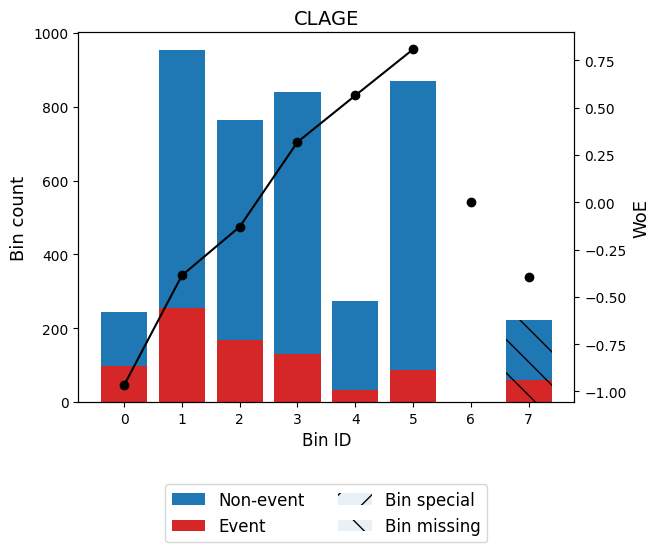

In [24]:
bin_CLAGE.binning_table.plot("woe")

In [25]:
bin_NINQ.binning_table.build()


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.50)",1760,0.42,1481,279,0.16,0.28,3.02e-02,3.76e-03
1,"[0.50, 1.50)",940,0.23,767,173,0.18,0.1,2.16e-03,2.69e-04
2,"[1.50, 2.50)",560,0.13,429,131,0.23,-0.2,5.91e-03,7.37e-04
3,"[2.50, 3.50)",286,0.07,206,80,0.28,-0.44,1.53e-02,1.90e-03
4,"[3.50, inf)",282,0.07,167,115,0.41,-1.02,8.97e-02,1.08e-02
5,Special,0,0.00,0,0,0.00,0.0,0.00e+00,0.00e+00
6,Missing,344,0.08,290,54,0.16,0.29,6.38e-03,7.95e-04
Totals,,4172,1.00,3340,832,0.20,,1.50e-01,1.82e-02


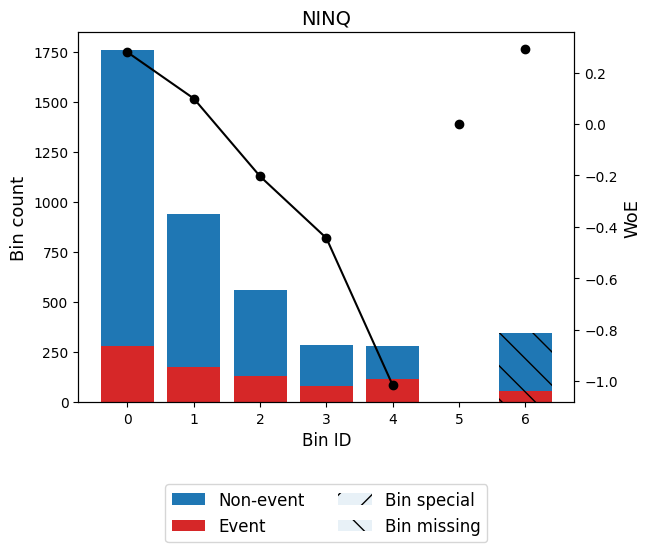

In [26]:
bin_NINQ.binning_table.plot("woe")


In [27]:
bin_LTV.binning_table.build()


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.71)",380,0.09,280,100,0.26,-0.36,1.31e-02,1.63e-03
1,"[0.71, 0.89)",1279,0.31,1049,230,0.18,0.13,4.80e-03,6.00e-04
2,"[0.89, 0.90)",216,0.05,145,71,0.33,-0.68,2.83e-02,3.48e-03
3,"[0.90, 0.95)",728,0.17,620,108,0.15,0.36,2.00e-02,2.48e-03
4,"[0.95, 0.96)",242,0.06,167,75,0.31,-0.59,2.37e-02,2.92e-03
5,"[0.96, inf)",915,0.22,796,119,0.13,0.51,4.87e-02,6.02e-03
6,Special,0,0.00,0,0,0.00,0.0,0.00e+00,0.00e+00
7,Missing,412,0.10,283,129,0.31,-0.6,4.25e-02,5.23e-03
Totals,,4172,1.00,3340,832,0.20,,1.81e-01,2.24e-02


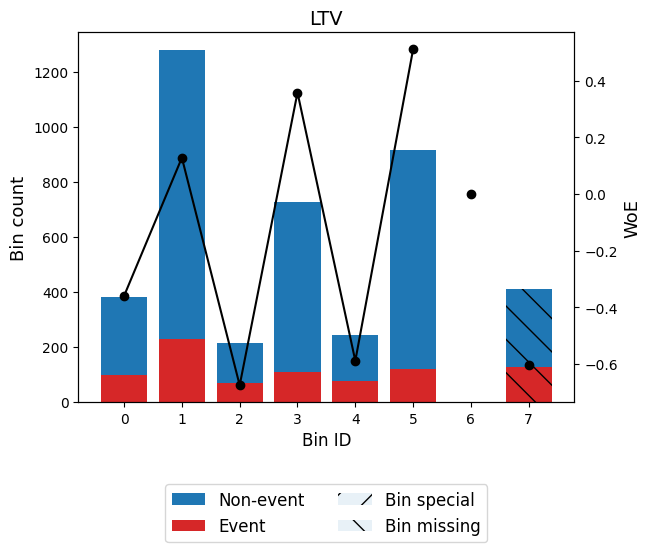

In [28]:
bin_LTV.binning_table.plot("woe")

In [29]:
bin_DEBTINC.binning_table.build()


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 30.78)",1039,0.25,987,52,0.05,1.55,0.36,4.12e-02
1,"[30.78, 34.48)",532,0.13,503,29,0.05,1.46,0.17,1.95e-02
2,"[34.48, 40.89)",1303,0.31,1206,97,0.07,1.13,0.28,3.28e-02
3,"[40.89, 42.30)",209,0.05,184,25,0.12,0.61,0.02,1.87e-03
4,"[42.30, inf)",209,0.05,130,79,0.38,-0.89,0.05,6.05e-03
5,Special,0,0.00,0,0,0.00,0.0,0.00,0.00e+00
6,Missing,880,0.21,330,550,0.62,-1.9,1.07,1.17e-01
Totals,,4172,1.00,3340,832,0.20,,1.94,2.18e-01


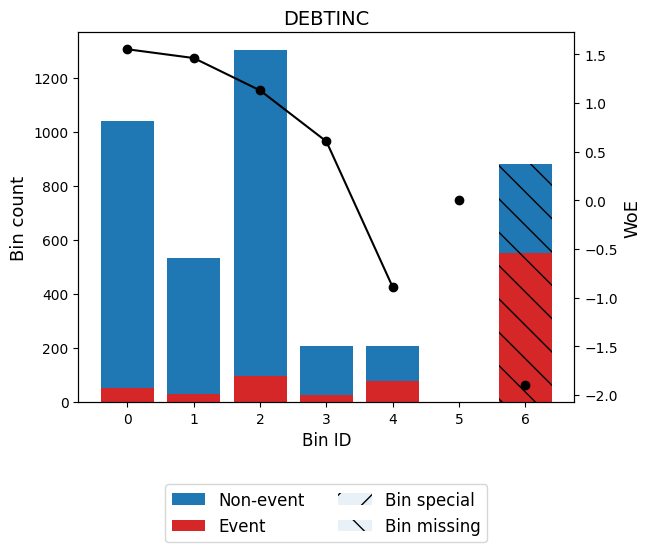

In [30]:
bin_DEBTINC.binning_table.plot("woe")

### 7. Preparación de datos para regresión

In [ ]:
# transformacion de numéricas a categóricas con los bins obtenidos
train["woe_LOAN"]    = bin_LOAN.transform(train["LOAN"], metric="woe")
train["woe_DELINQ"]  = bin_DELINQ.transform(train["DELINQ"], metric="woe")
train["woe_DEROG"]   = bin_DEROG.transform(train["DEROG"], metric="woe")
train["woe_YOJ"]     = bin_YOJ.transform(train["YOJ"], metric="woe")
train["woe_CLNO"]    = bin_CLNO.transform(train["CLNO"], metric="woe")
train["woe_NINQ"]    = bin_NINQ.transform(train["NINQ"], metric="woe")
train["woe_LTV"]     = bin_LTV.transform(train["LTV"], metric="woe")
train["woe_DEBTINC"] = bin_DEBTINC.transform(train["DEBTINC"], metric="woe")
train["woe_CLAGE"] = bin_CLAGE.transform(train["CLAGE"], metric="woe")

In [42]:
train.columns

Index(['BAD', 'LOAN', 'REASON', 'JOB', 'YOJ', 'DEROG', 'DELINQ', 'CLAGE',
       'NINQ', 'CLNO', 'DEBTINC', 'LTV', 'woe_LOAN', 'woe_DELINQ', 'woe_DEROG',
       'woe_YOJ', 'woe_CLNO', 'woe_NINQ', 'woe_LTV', 'woe_DEBTINC',
       'woe_CLAGE'],
      dtype='object')

In [43]:
#comprobar que no hay NA en las variables transformadas
train[[c for c in train.columns if c.startswith("woe_")]].isna().sum()

woe_LOAN       0
woe_DELINQ     0
woe_DEROG      0
woe_YOJ        0
woe_CLNO       0
woe_NINQ       0
woe_LTV        0
woe_DEBTINC    0
woe_CLAGE      0
dtype: int64

In [ ]:
test["woe_LOAN"]     = bin_LOAN.transform(test["LOAN"], metric="woe")
test["woe_DELINQ"]   = bin_DELINQ.transform(test["DELINQ"], metric="woe")
test["woe_DEROG"]    = bin_DEROG.transform(test["DEROG"], metric="woe")
test["woe_YOJ"]      = bin_YOJ.transform(test["YOJ"], metric="woe")
test["woe_CLNO"]     = bin_CLNO.transform(test["CLNO"], metric="woe")
test["woe_NINQ"]     = bin_NINQ.transform(test["NINQ"], metric="woe")
test["woe_LTV"]      = bin_LTV.transform(test["LTV"], metric="woe")
test["woe_DEBTINC"]  = bin_DEBTINC.transform(test["DEBTINC"], metric="woe")
test["woe_CLAGE"]  = bin_CLAGE.transform(test["CLAGE"],  metric="woe")

In [45]:
test.columns

Index(['BAD', 'LOAN', 'REASON', 'JOB', 'YOJ', 'DEROG', 'DELINQ', 'CLAGE',
       'NINQ', 'CLNO', 'DEBTINC', 'LTV', 'woe_LOAN', 'woe_DELINQ', 'woe_DEROG',
       'woe_YOJ', 'woe_CLNO', 'woe_NINQ', 'woe_LTV', 'woe_DEBTINC',
       'woe_CLAGE'],
      dtype='object')

In [54]:
# correlacion
variables_relevantes = [
    "woe_LOAN",
    "woe_DELINQ",
    "woe_DEROG",
    "woe_YOJ",
    "woe_CLNO",
    "woe_NINQ",
    "woe_LTV",
    "woe_DEBTINC",
    "woe_CLAGE"
]

correlations = train[variables_relevantes].corr()
correlations

,woe_LOAN,woe_DELINQ,woe_DEROG,woe_YOJ,woe_CLNO,woe_NINQ,woe_LTV,woe_DEBTINC,woe_CLAGE
woe_LOAN,1.00,6.15e-02,2.02e-02,0.08,9.41e-02,-0.03,0.05,0.13,9.71e-02
woe_DELINQ,0.06,1.00e+00,2.24e-01,-0.02,-1.00e-01,0.06,0.10,0.17,-4.28e-03
woe_DEROG,0.02,2.24e-01,1.00e+00,0.05,1.94e-03,0.17,0.04,0.16,6.90e-02
woe_YOJ,0.08,-2.00e-02,5.48e-02,1.00,7.58e-02,0.07,-0.02,0.05,1.71e-01
woe_CLNO,0.09,-1.00e-01,1.94e-03,0.08,1.00e+00,-0.04,0.04,-0.02,2.01e-01
woe_NINQ,-0.03,6.38e-02,1.66e-01,0.07,-4.14e-02,1.00,-0.02,0.18,8.78e-02
woe_LTV,0.05,1.01e-01,4.38e-02,-0.02,3.59e-02,-0.02,1.00,0.12,-4.30e-02
woe_DEBTINC,0.13,1.73e-01,1.59e-01,0.05,-1.98e-02,0.18,0.12,1.00,6.15e-02
woe_CLAGE,0.10,-4.28e-03,6.90e-02,0.17,2.01e-01,0.09,-0.04,0.06,1.00e+00


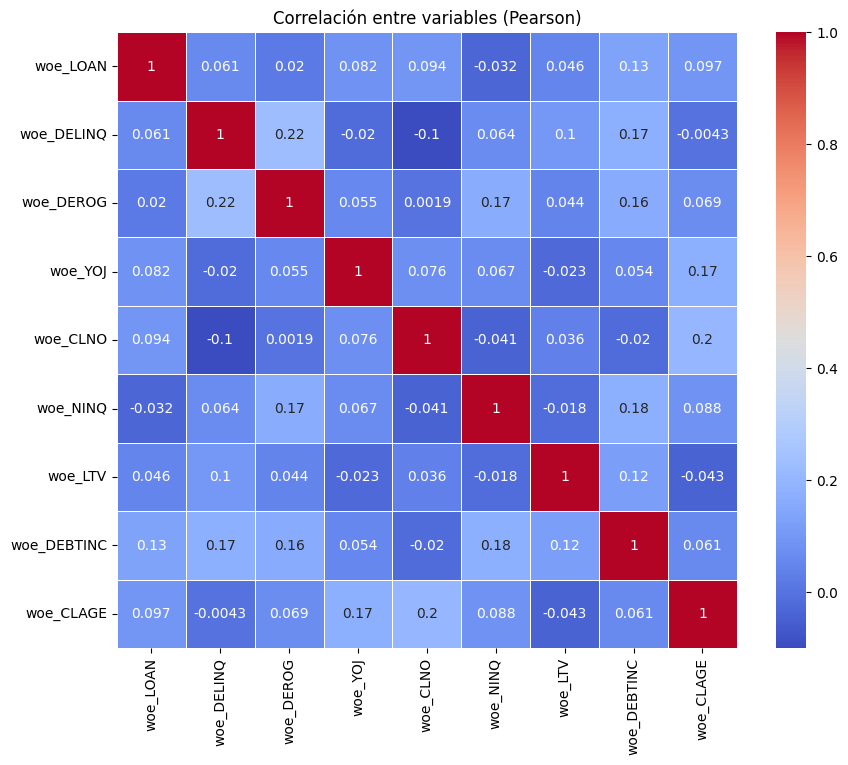

In [55]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlations, 
            annot=True, 
            cmap="coolwarm", 
            linewidths=0.5)

plt.title("Correlación entre variables (Pearson)")
plt.show()

# No hay multicolinealidad relevante y no es necesario eliminar ninguna por correlación.

In [56]:
# las variables relevantes para el modelo serán las transformadas con WoE
formula = "BAD ~ " + " + ".join(variables_relevantes)
formula

'BAD ~ woe_LOAN + woe_DELINQ + woe_DEROG + woe_YOJ + woe_CLNO + woe_NINQ + woe_LTV + woe_DEBTINC + woe_CLAGE'

### 8. Modelo Logístico con Variables en WoE

El modelo estimado es un **GLM binomial con función de enlace logit**, cuya forma funcional es:

$$
\log\left(\frac{PD}{1 - PD}\right) 
= \beta_0 
+ \beta_1 \cdot WoE_1 
+ \beta_2 \cdot WoE_2 
+ \dots 
+ \beta_k \cdot WoE_k
$$

Donde:

- \( PD \) es la **Probabilidad de Incumplimiento (Probability of Default)**.
- \( \frac{PD}{1-PD} \) representa los **odds de default**.
- \( \log\left(\frac{PD}{1-PD}\right) \) es el **log-odds**.
- \( \beta_0 \) es el intercepto.
- \( \beta_i \) es el coeficiente asociado a cada variable transformada en **Weight of Evidence (WoE)**.

Despejando la probabilidad:

$$
PD = \frac{1}{1 + e^{-\left(\beta_0 + \sum_{i=1}^{k} \beta_i \cdot WoE_i\right)}}
$$

In [57]:
# Estimación del modelo de regresión logística con statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf

model = smf.glm(
    formula=formula,
    data=train,
    family=sm.families.Binomial(link=sm.families.links.logit())
).fit()

print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                    BAD   No. Observations:                 4172
Model:                            GLM   Df Residuals:                     4162
Model Family:                Binomial   Df Model:                            9
Link Function:                  logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1269.7
Date:               sá., 14 mar. 2026   Deviance:                       2539.5
Time:                        18:57:38   Pearson chi2:                 4.49e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3233
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -0.3460      0.063     -5.491      

El WoE está definido como:
$$
    WoE_i = \ln \left( \frac{N_{Good,i} / N_{Good}}{N_{Bad,i} / N_{Bad}} \right)
$$
Por lo tanto un bin tiene mas riesgo cuanto mas negativo sea WoE

Pseudo R-squ. (CS):0.3062 indica una capacidad explicativa elevada para un modelo binario retail

Todos los p-values son inferiores a 0.01. Esto implica:

    Todas las variables aportan información marginal adicional.
    No hay variables irrelevantes.
    El modelo es estadísticamente sólido.

### 9. Evaluación

In [58]:
pr_train = model.predict(train)
pr_test  = model.predict(test)

auc_train = roc_auc_score(train["BAD"], pr_train)
auc_test  = roc_auc_score(test["BAD"], pr_test)

gini_train = 2 * auc_train - 1
gini_test  = 2 * auc_test - 1

print("AUC Train:", round(auc_train,4))
print("AUC Test :", round(auc_test,4))
print("Gini Train:", round(gini_train,4))
print("Gini Test :", round(gini_test,4))

AUC Train: 0.8943
AUC Test : 0.8832
Gini Train: 0.7886
Gini Test : 0.7664


En esta fase se ha estimado un modelo de Regresión Logística utilizando como variables explicativas las variables previamente transformadas mediante Weight of Evidence (WoE).
El flujo metodológico seguido ha sido:

    División de la muestra en entrenamiento y validación (70/30 estratificado).
    Binning óptimo de cada variable en la muestra de entrenamiento.
    Transformación de cada variable a su correspondiente WoE.
    Verificación de ausencia de correlaciones relevantes.
    Estimación de un modelo GLM binomial con las variables WoE.
    Evaluación de la capacidad discriminatoria mediante AUC y Gini.

Este enfoque replica la metodología clásica de construcción de scorecards bancarios interpretables, los cuales serán mostrados más adelante.
Pseudo R-squ. (CS):0.3062 indica una capacidad explicativa elevada para un modelo binario retail

¿usar 1KS statistic
Gini
Lift curve?
¿lo que exige:
IFRS9 model validation
IRB scorecard validation?

### 10. Score Band Report
Score Band Report (interpretabilidad global del modelo WoE)
        ├── Tramos de score con PD esperada vs PD observada
        ├── Calibración visual por tramo (Development vs Hold-out)
        └── % aprobado acumulado → herramienta de política crediticia

Score band | PD esperada | # obs | # good | # bad | % total | % aprobado acumulado | PD observada

<center>
~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.<br>
                          THIS IS THE END OF THE NOTEBOOK<br>
~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.<br>
</center>